In [1]:
import os
import warnings
import pandas as pd
import tqdm

pd.set_option('display.max_columns', None)
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)
warnings.filterwarnings(action="ignore", message="credentials were not supplied. open data access only")

from socceraction.data.statsbomb import StatsBombLoader
import socceraction.spadl as spadl

In [2]:
SBL = StatsBombLoader(getter="remote", creds={"user": None, "passwd": None})

In [3]:
# View all available competitions
competitions = SBL.competitions()
set(competitions.competition_name)

{'1. Bundesliga',
 'African Cup of Nations',
 'Champions League',
 'Copa America',
 'Copa del Rey',
 "FA Women's Super League",
 'FIFA U20 World Cup',
 'FIFA World Cup',
 'Frauen Bundesliga',
 'Indian Super league',
 'La Liga',
 'Liga F',
 'Liga Profesional',
 'Ligue 1',
 'Major League Soccer',
 'NWSL',
 'North American League',
 'Premier League',
 'Serie A',
 'Serie A Women',
 'UEFA Euro',
 'UEFA Europa League',
 "UEFA Women's Euro",
 "Women's World Cup"}

In [4]:
selected_competitions = competitions[
    (competitions.competition_name == "FIFA World Cup")
    & (competitions.season_name == "2022")
]

selected_competitions

,season_id,competition_id,competition_name,country_name,competition_gender,season_name
30,106,43,FIFA World Cup,International,male,2022


In [5]:
games = pd.concat([
    SBL.games(row.competition_id, row.season_id)
    for row in selected_competitions.itertuples()
])
games[["home_team_id", "away_team_id", "game_date", "home_score", "away_score"]]

,home_team_id,away_team_id,game_date,home_score,away_score
0,1833,788,2022-12-01 15:00:00,1,2
1,768,797,2022-11-21 13:00:00,6,2
2,785,782,2022-12-01 15:00:00,0,0
3,941,3565,2022-11-25 16:00:00,1,1
4,778,772,2022-12-01 19:00:00,2,1
...,...,...,...,...,...
59,772,795,2022-11-23 16:00:00,7,0
60,785,1833,2022-11-27 16:00:00,4,1
61,2722,781,2022-12-02 19:00:00,1,0
62,771,792,2022-11-22 19:00:00,4,1


In [6]:
games_list = []
for row in selected_competitions.itertuples():
    games_list.append(SBL.games(row.competition_id, row.season_id))

In [7]:
games_verbose = tqdm.tqdm(list(games.itertuples()), desc="Loading game data")
teams, players = [], []
actions = {}
for game in games_verbose:
    # load data
    teams.append(SBL.teams(game.game_id))
    players.append(SBL.players(game.game_id))
    events = SBL.events(game.game_id)
    # convert data
    actions[game.game_id] = spadl.statsbomb.convert_to_actions(
        events, 
        home_team_id=game.home_team_id,
        xy_fidelity_version=1,
        shot_fidelity_version=1
    )

teams = pd.concat(teams).drop_duplicates(subset="team_id")
players = pd.concat(players)

Loading game data:   0%|          | 0/64 [00:00<?, ?it/s]c:\Users\Oluwanifemi\anaconda3\Lib\site-packages\socceraction\data\statsbomb\loader.py:337: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  eventsdf["under_pressure"] = eventsdf["under_pressure"].fillna(False).astype(bool)
c:\Users\Oluwanifemi\anaconda3\Lib\site-packages\socceraction\data\statsbomb\loader.py:338: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  eventsdf["counterpress"] = eventsdf["counterpress"].fillna(False).astype(bool)
c:\Users\Oluwanifemi\anaconda3\Lib\site-packages\socceraction\dat

In [8]:
print(f"Teams: {len(teams)}, Player records: {len(players)}")

Teams: 32, Player records: 1995


In [9]:
datafolder = "data"

# Create data folder if it doesn't exist
if not os.path.exists(datafolder):
    os.mkdir(datafolder)
    print(f"Directory {datafolder} created.")

spadl_h5 = os.path.join(datafolder, "spadl-statsbomb.h5")

# Store all spadl data in h5-file
with pd.HDFStore(spadl_h5) as spadlstore:
    spadlstore["competitions"] = selected_competitions
    spadlstore["games"] = games
    spadlstore["teams"] = teams
    spadlstore["players"] = players[['player_id', 'player_name', 'nickname']].drop_duplicates(subset='player_id')
    spadlstore["player_games"] = players[['player_id', 'game_id', 'team_id', 'is_starter', 'starting_position_id', 'starting_position_name', 'minutes_played']]
    for game_id in actions.keys():
        spadlstore[f"actions/game_{game_id}"] = actions[game_id]

In [10]:
spadl_h5 = "data/spadl-statsbomb.h5"

with pd.HDFStore(spadl_h5) as spadlstore:
    games = spadlstore["games"]
    teams = spadlstore["teams"]
    players = spadlstore["players"]
    player_games = spadlstore["player_games"]  # has minutes_played!
    
    # Load ALL actions into one DataFrame
    all_actions = pd.concat([
        spadlstore[f"actions/game_{game_id}"].assign(game_id=game_id)
        for game_id in games["game_id"]
    ])

print(f"Total actions across all games: {len(all_actions):,}")

Total actions across all games: 138,944


## Compute xT

In [11]:
all_actions = (
    all_actions
    .merge(spadl.actiontypes_df(), how="left")
    .merge(spadl.results_df(), how="left")
    .merge(spadl.bodyparts_df(), how="left")
)

In [12]:
all_actions

,game_id,original_event_id,period_id,time_seconds,team_id,player_id,start_x,start_y,end_x,end_y,type_id,result_id,bodypart_id,action_id,type_name,result_name,bodypart_name
0,3857276,05a57281-9295-408a-9c4f-e32d7fad4d96,1,0.460,788,6301.0,52.0625,33.660,63.0000,34.680,0,1,4,0,pass,success,foot_left
1,3857276,fa742b13-32df-4dce-8b08-7c6ebb125d5a,1,1.295,788,5234.0,63.0000,34.680,63.0875,35.700,21,1,0,1,dribble,success,foot
2,3857276,3a06bcce-1408-4a0b-be01-f6b93f142b30,1,2.415,788,5234.0,63.0875,35.700,78.7500,49.725,0,1,5,2,pass,success,foot_right
3,3857276,15c4c6ba-c038-474a-9c61-d0190ce84829,1,3.886,788,12149.0,78.7500,49.725,78.4000,49.725,21,1,0,3,dribble,success,foot
4,3857276,1f1b0ef8-1a1d-45b3-bf9c-4299ea836377,1,5.143,788,12149.0,78.4000,49.725,79.3625,22.440,0,1,4,4,pass,success,foot_left
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
138939,3857262,b124b025-61d7-4df2-8438-c564d20ef858,2,3102.163,791,3083.0,76.6500,1.955,69.2125,3.655,0,1,4,2012,pass,success,foot_left
138940,3857262,3b68b936-010c-4b69-927c-8568f3a22fc6,2,3103.533,791,40672.0,68.9500,4.335,71.2250,6.970,0,0,4,2013,pass,fail,foot_left
138941,3857262,82c6aa14-4d63-43f5-b030-a203612cf383,2,3104.180,780,3193.0,72.0125,6.205,45.8500,10.540,0,0,4,2014,pass,fail,foot_left
138942,3857262,55b541af-b1fe-4f28-9931-47495c22055b,2,3106.306,791,5618.0,45.0625,11.305,53.9000,0.000,18,1,1,2015,clearance,success,head


In [13]:
print(all_actions.shape)
print(all_actions['type_name'].value_counts())

(138944, 17)
type_name
pass                60855
dribble             56707
clearance            2684
throw_in             2589
tackle               2185
interception         1851
take_on              1793
foul                 1775
bad_touch            1758
shot                 1384
cross                1353
freekick_short       1171
goalkick              977
freekick_crossed      572
corner_crossed        440
keeper_save           331
keeper_claim          208
corner_short          122
keeper_punch           79
shot_penalty           64
shot_freekick          46
Name: count, dtype: int64


In [14]:
from socceraction.xthreat import ExpectedThreat

In [15]:
xt_model = ExpectedThreat(l=16, w=12)
xt_model.fit(all_actions)

print(f"xT grid shape: {xt_model.xT.shape}")
print(f"Max xT value: {xt_model.xT.max():.4f}")
print(f"Min xT value: {xt_model.xT.min():.4f}")

# iterations:  49
xT grid shape: (12, 16)
Max xT value: 0.0725
Min xT value: 0.0034


In [16]:
all_actions['xt_value'] = xt_model.rate(all_actions)

In [17]:
moves = all_actions[all_actions['type_name'].isin(["pass","dribble","cross"])].copy()
successful_moves = moves[moves['result_name'] == "success"].copy()


print(f"Total moves: {len(moves):,}")
print(f"Successful moves: {len(successful_moves):,}")
print(f"Successful pass rate: {len(successful_moves) / len(moves):.1%}")
print(f"\nMean xT per successful move: {successful_moves['xt_value'].mean():.5f}")
print(f"Max xT single move: {successful_moves['xt_value'].max():.4f}")

Total moves: 118,915
Successful moves: 108,527
Successful pass rate: 91.3%

Mean xT per successful move: -0.00002
Max xT single move: 0.0660


In [18]:
top_action = successful_moves.sort_values("xt_value", ascending=False).head(10)

top_action_named = (
    top_action
    .merge(players[['player_id', 'player_name']], left_on='player_id', right_on='player_id', how='left')
    .merge(teams[['team_id', 'team_name']], left_on='team_id', right_on='team_id', how='left')
)

top_action_named[["player_name", "team_name", "type_name", "result_name", "start_x", "start_y", "end_x", "end_y", "xt_value"]]


,player_name,team_name,type_name,result_name,start_x,start_y,end_x,end_y,xt_value
0,Nicolas Alexis Julio N'Koulou Ndoubena,Cameroon,pass,success,63.1750,6.460,98.7000,32.895,0.066018
1,Antonee Robinson,United States,pass,success,70.1750,2.295,98.9625,29.070,0.065307
2,Pervis Josué Estupiñán Tenorio,Ecuador,pass,success,71.1375,32.640,98.8750,33.575,0.064466
3,Antonio Rüdiger,Germany,pass,success,68.6875,14.875,99.7500,31.280,0.064341
4,Luka Modrić,Croatia,cross,success,98.2625,2.550,100.2750,28.645,0.064182
5,Atiba Hutchinson,Canada,pass,success,76.7375,9.860,102.2000,28.815,0.063642
6,Tim Ream,United States,pass,success,76.5625,7.310,98.4375,30.600,0.063642
7,Mohammed Al Burayk,Saudi Arabia,pass,success,80.3250,4.760,100.1000,30.940,0.063459
8,Abdelhamid Sabiri,Morocco,pass,success,77.3500,29.325,99.4000,32.810,0.062979
9,Kamal Miller,Canada,pass,success,99.8375,9.605,101.5000,30.430,0.062896


In [19]:
# Break down successful moves by action type
breakdown = successful_moves.groupby('type_name').agg(
    count=('xt_value', 'count'),
    mean_xt=('xt_value', 'mean'),
    sum_xt=('xt_value', 'sum')
).round(5)

print(breakdown)
print(f"\nOverall success rate by type:")
print(moves.groupby('type_name').apply(
    lambda g: (g['result_name'] == 'success').mean()
).round(3))


           count  mean_xt    sum_xt
type_name                          
cross        429  0.02096   8.99106
dribble    56707 -0.00025 -14.23001
pass       51391  0.00006   3.04201

Overall success rate by type:
type_name
cross      0.317
dribble    1.000
pass       0.844
dtype: float64


C:\Users\Oluwanifemi\AppData\Local\Temp\ipykernel_2708\365517148.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(moves.groupby('type_name').apply(


In [20]:
successful_passes = all_actions[
    (all_actions['type_name'].isin(['pass', 'cross'])) & 
    (all_actions['result_name'] == 'success')
].copy()

print(f"Successful passes (incl. crosses): {len(successful_passes):,}")
print(f"Mean xT per successful pass: {successful_passes['xt_value'].mean():.5f}")
print(f"Total xT created via passing: {successful_passes['xt_value'].sum():.1f}")

Successful passes (incl. crosses): 51,820
Mean xT per successful pass: 0.00023
Total xT created via passing: 12.0


## DEBUGGING AND UNDERSTANDING


xT grid shape: (12, 16)

xT values across the grid (each row = one strip across the pitch width):
Columns go from 0 (one end of pitch) to 15 (other end)

Row  0: 0.003 0.006 0.006 0.007 0.007 0.006 0.006 0.006 0.006 0.007 0.008 0.009 0.010 0.010 0.011 0.008
Row  1: 0.006 0.007 0.008 0.007 0.007 0.006 0.006 0.006 0.006 0.007 0.008 0.011 0.011 0.013 0.012 0.012
Row  2: 0.009 0.011 0.010 0.009 0.007 0.007 0.006 0.006 0.006 0.007 0.009 0.010 0.013 0.018 0.015 0.012
Row  3: 0.010 0.013 0.010 0.009 0.007 0.006 0.006 0.006 0.007 0.007 0.008 0.010 0.013 0.018 0.026 0.016
Row  4: 0.027 0.030 0.013 0.009 0.007 0.007 0.006 0.006 0.006 0.007 0.008 0.010 0.012 0.023 0.048 0.033
Row  5: 0.041 0.029 0.017 0.011 0.010 0.006 0.006 0.006 0.006 0.007 0.008 0.010 0.016 0.034 0.060 0.057
Row  6: 0.067 0.024 0.009 0.014 0.007 0.007 0.006 0.006 0.007 0.007 0.008 0.010 0.012 0.026 0.047 0.073
Row  7: 0.027 0.027 0.013 0.009 0.008 0.006 0.006 0.006 0.006 0.007 0.008 0.010 0.012 0.024 0.027 0.027
Row  8: 0.008 

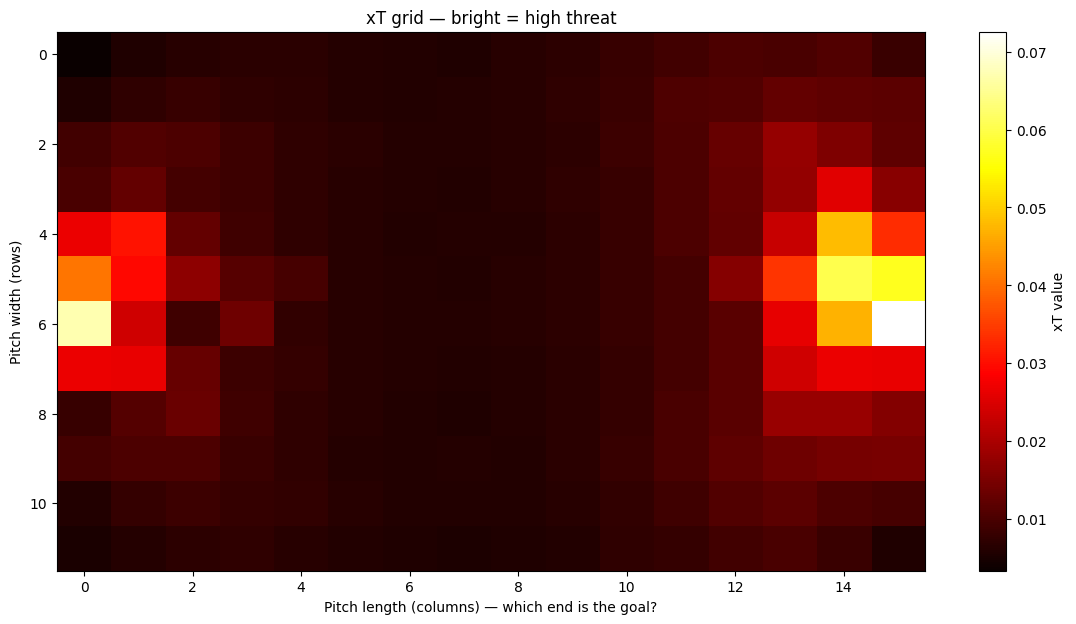

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# Look at the xT grid as a heatmap
print("xT grid shape:", xt_model.xT.shape)
print("\nxT values across the grid (each row = one strip across the pitch width):")
print("Columns go from 0 (one end of pitch) to 15 (other end)")
print()

# Print the grid with formatting
grid = xt_model.xT
for i in range(grid.shape[0]):
    row_str = " ".join(f"{v:.3f}" for v in grid[i])
    print(f"Row {i:2d}: {row_str}")

print(f"\nMax xT at grid position: row={np.unravel_index(grid.argmax(), grid.shape)[0]}, col={np.unravel_index(grid.argmax(), grid.shape)[1]}")
print(f"Min xT at grid position: row={np.unravel_index(grid.argmin(), grid.shape)[0]}, col={np.unravel_index(grid.argmin(), grid.shape)[1]}")

# Visualize it
fig, ax = plt.subplots(figsize=(14, 7))
im = ax.imshow(grid, cmap='hot', aspect='auto')
ax.set_xlabel('Pitch length (columns) — which end is the goal?')
ax.set_ylabel('Pitch width (rows)')
ax.set_title('xT grid — bright = high threat')
plt.colorbar(im, ax=ax, label='xT value')
plt.savefig('outputs/xt_grid_diagnostic.png', dpi=100, bbox_inches='tight')
plt.show()

In [22]:
# Get all of Messi's successful passes into the danger zone
messi_id = players[players['player_name'].str.contains('Messi', na=False)]['player_id'].values[0]
print(f"Messi player_id: {messi_id}")

messi_passes = successful_passes[
    (successful_passes['player_id'] == messi_id) &
    (successful_passes['end_x'] >= 90) &
    (successful_passes['start_x'] >= 60)
].copy()

print(f"\nMessi's {len(messi_passes)} 'creative passes':")
print(messi_passes[['start_x', 'start_y', 'end_x', 'end_y', 'type_name', 'xt_value']].to_string(index=False))

Messi player_id: 5503

Messi's 18 'creative passes':
 start_x  start_y    end_x  end_y type_name  xt_value
 66.5875   38.080 101.2375 60.860      pass  0.003665
 70.0000   27.795  91.5250 55.930      pass  0.009891
 77.7000   18.445  95.9875 20.145      pass  0.008168
 80.6750   27.965 101.7625 62.135      pass  0.000100
 80.4125   16.660  97.4750  8.840      pass -0.001996
 80.8500   13.345  94.5000 18.105      pass  0.005922
 90.0375   36.465  93.9750 27.795      pass -0.007213
 80.8500   17.340  97.1250 12.070      pass  0.002861
 92.3125   46.920  92.5750 65.280      pass -0.014994
 84.7875   39.270  97.3000 52.700      pass -0.000824
 88.9000   30.600  93.7125 41.310      pass  0.021991
 79.3625   38.505  90.8250 43.605      pass  0.006681
 87.5000    6.290  90.5625  3.655      pass -0.001731
 83.8250   41.820  95.2000 50.320      pass  0.013427
101.8500   23.290  98.7000 29.835     cross  0.045928
 97.8250   65.535  91.4375 65.110      pass -0.000797
 74.6375   37.400  99.1375 57

In [23]:
# What's the average xT for passes ending at different x positions?
print("\nMean xT of passes by ending zone (end_x bucket):")
successful_passes['end_zone'] = pd.cut(successful_passes['end_x'], bins=[0, 35, 70, 85, 95, 105])
print(successful_passes.groupby('end_zone', observed=True)['xt_value'].agg(['count', 'mean']))

# And by start_x bucket
print("\nMean xT of passes by starting zone (start_x bucket):")
successful_passes['start_zone'] = pd.cut(successful_passes['start_x'], bins=[0, 35, 70, 85, 95, 105])
print(successful_passes.groupby('start_zone', observed=True)['xt_value'].agg(['count', 'mean']))


Mean xT of passes by ending zone (end_x bucket):
           count      mean
end_zone                  
(0, 35]    12946  0.000757
(35, 70]   26482 -0.000710
(70, 85]    8074 -0.001381
(85, 95]    2942  0.003141
(95, 105]   1376  0.016672

Mean xT of passes by starting zone (start_x bucket):
            count      mean
start_zone                 
(0, 35]     12461 -0.000117
(35, 70]    27410  0.000683
(70, 85]     8003  0.002113
(85, 95]     2702 -0.003367
(95, 105]    1244 -0.010481


In [24]:
# Total minutes per player across the tournament
minutes_per_player = (
    player_games.groupby('player_id')['minutes_played']
    .sum()
    .reset_index(name='total_minutes')
)

# Aggregate xT by player from successful passes + crosses
xt_by_player = (
    successful_passes
    .groupby('player_id')
    .agg(
        total_xt=('xt_value', 'sum'),
        passes_completed=('xt_value', 'count'),
    )
    .reset_index()
)

# Merge minutes and player metadata
xt_by_player = (
    xt_by_player
    .merge(minutes_per_player, on='player_id', how='left')
    .merge(players[['player_id', 'player_name', 'nickname']], on='player_id', how='left')
)

# Use nickname when available, else full name (the tutorial pattern)
xt_by_player['display_name'] = xt_by_player.apply(
    lambda r: r['nickname'] if pd.notna(r['nickname']) and r['nickname'] else r['player_name'],
    axis=1
)

# Compute per-90 metric
xt_by_player['xt_per_90'] = (xt_by_player['total_xt'] / xt_by_player['total_minutes']) * 90

# Qualify only players with at least 270 minutes (≈3 full matches)
qualified = xt_by_player[xt_by_player['total_minutes'] >= 270].copy()

# Two rankings to print: by total xT and by per-90 rate
print("=== TOP 15 by TOTAL xT (volume creators) ===")
print(
    qualified
    .sort_values('total_xt', ascending=False)
    .head(15)[['display_name', 'total_minutes', 'passes_completed', 'total_xt', 'xt_per_90']]
    .to_string(index=False)
)

print("\n\n=== TOP 15 by xT PER 90 (efficient creators) ===")
print(
    qualified
    .sort_values('xt_per_90', ascending=False)
    .head(15)[['display_name', 'total_minutes', 'passes_completed', 'total_xt', 'xt_per_90']]
    .to_string(index=False)
)

=== TOP 15 by TOTAL xT (volume creators) ===
    display_name  total_minutes  passes_completed  total_xt  xt_per_90
    Dejan Lovren            652               391  0.884304   0.122067
  Jurriën Timber            434               273  0.762143   0.158048
            Pepe            397               247  0.691864   0.156846
 Antonio Rüdiger            302               219  0.628701   0.187361
  Joško Gvardiol            749               453  0.610284   0.073332
      Marquinhos            466               333  0.589334   0.113820
Joachim Andersen            299               196  0.571461   0.172012
      Nathan Aké            532               303  0.533869   0.090316
       Luke Shaw            482               296  0.524103   0.097861
 Aymeric Laporte            330               391  0.523936   0.142892
Nicolás Otamendi            786               514  0.518494   0.059369
   Harry Maguire            479               342  0.515554   0.096868
  Theo Hernández            571 

In [ ]:
# Real "creators": passes that end deep in the attacking zone
final_third_progression = successful_passes[
    (successful_passes['end_x'] >= 90) & 
    (successful_passes['start_x'] >= 60)
].copy()

print(f"Final-third progressions (passes ending past x=90, starting past x=60): {len(final_third_progression):,}")
print(f"Mean xT per pass: {final_third_progression['xt_value'].mean():.4f}")

xt_creators = (
    final_third_progression
    .groupby('player_id')
    .agg(total_xt=('xt_value', 'sum'),
         creative_passes=('xt_value', 'count'))
    .reset_index()
    .merge(minutes_per_player, on='player_id', how='left')
    .merge(players[['player_id', 'player_name', 'nickname']], on='player_id', how='left')
)
xt_creators['display_name'] = xt_creators.apply(
    lambda r: r['nickname'] if pd.notna(r['nickname']) and r['nickname'] else r['player_name'],
    axis=1
)
xt_creators['xt_per_90'] = (xt_creators['total_xt'] / xt_creators['total_minutes']) * 90

qualified_creators = xt_creators[
    (xt_creators['total_minutes'] >= 270) & 
    (xt_creators['creative_passes'] >= 15)
]

print("\n=== TOP 15 TRUE CREATORS (passes ending in the danger zone) ===")
print(
    qualified_creators
    .sort_values('total_xt', ascending=False)
    .head(15)[['display_name', 'total_minutes', 'creative_passes', 'total_xt', 'xt_per_90']]
    .to_string(index=False)
)


Final-third progressions (passes ending past x=90, starting past x=60): 2,588
Mean xT per pass: 0.0116

=== TOP 15 TRUE CREATORS (passes ending in the danger zone) ===
    display_name  total_minutes  creative_passes  total_xt  xt_per_90
    Dejan Lovren            652               24  0.629099   0.086839
   Harry Souttar            401               20  0.584965   0.131289
  Joško Gvardiol            749               22  0.575514   0.069154
      Kye Rowles            401               27  0.542970   0.121864
Walker Zimmerman            313               17  0.447899   0.128789
 Antonio Rüdiger            302               16  0.377186   0.112407
   Kylian Mbappé            686               20  0.347391   0.045576
    Nayef Aguerd            379               16  0.300493   0.071357
   Manuel Akanji            393               17  0.274240   0.062803
    Ivan Perišić            714               21  0.230129   0.029008
 Ousmane Dembélé            463               16  0.229246   0

Lovren passes to plot: 391
Messi passes to plot: 286


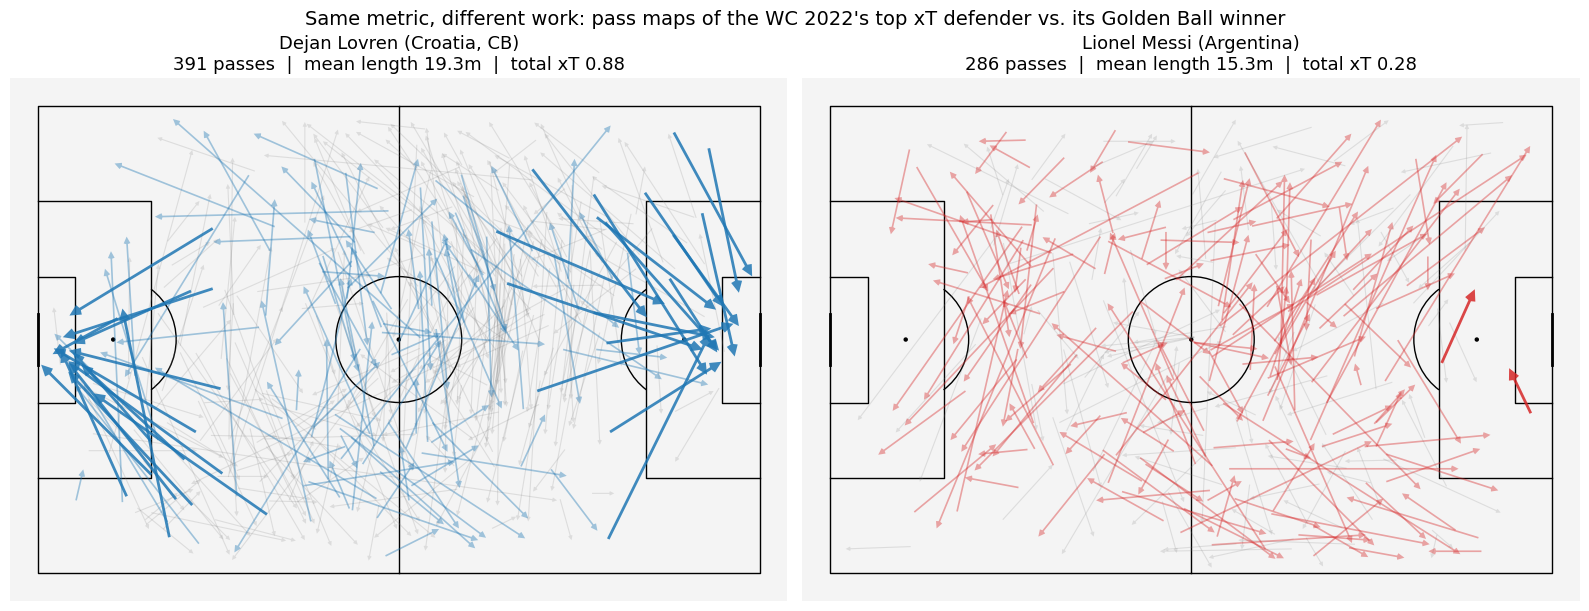

In [27]:

lovren_id = players[players['player_name'].str.contains('Lovren', na=False)]['player_id'].values[0]
messi_id = players[players['player_name'].str.contains('Messi', na=False)]['player_id'].values[0]

# Get every successful pass for each player (from the WC 2022)
lovren_passes = successful_passes[successful_passes['player_id'] == lovren_id].copy()
messi_passes = successful_passes[successful_passes['player_id'] == messi_id].copy()

print(f"Lovren passes to plot: {len(lovren_passes)}")
print(f"Messi passes to plot: {len(messi_passes)}")

# Create a SPADL-coordinate pitch (105m × 68m, attacking left-to-right)
pitch = Pitch(
    pitch_type='custom',
    pitch_length=105,
    pitch_width=68,
    line_color='black',
    linewidth=1,
    pitch_color='#f4f4f4'
)

fig, axs = pitch.draw(nrows=1, ncols=2, figsize=(16, 6))

def plot_player_passes(ax, passes_df, player_name, color):
    """Plot all successful passes for a single player with arrows colored by xT."""
    # Sort so the highest-xT passes draw last (on top)
    passes_df = passes_df.sort_values('xt_value')
    
    # Color: low/negative xT = grey, high positive xT = vivid
    for _, p in passes_df.iterrows():
        xt = p['xt_value']
        if xt > 0.02:
            line_color = color
            alpha = 0.85
            width = 2.0
        elif xt > 0:
            line_color = color
            alpha = 0.4
            width = 1.2
        else:
            line_color = 'grey'
            alpha = 0.2
            width = 0.8
        
        pitch.arrows(
            p['start_x'], p['start_y'],
            p['end_x'], p['end_y'],
            ax=ax,
            color=line_color,
            alpha=alpha,
            width=width,
            headwidth=4,
            headlength=4
        )
    
    # Stats annotation
    mean_len = np.sqrt(
        (passes_df['end_x'] - passes_df['start_x'])**2 +
        (passes_df['end_y'] - passes_df['start_y'])**2
    ).mean()
    total_xt = passes_df['xt_value'].sum()
    
    ax.set_title(
        f"{player_name}\n"
        f"{len(passes_df)} passes  |  mean length {mean_len:.1f}m  |  total xT {total_xt:.2f}",
        fontsize=13
    )

# Lovren on the left (blue), Messi on the right (red)
plot_player_passes(axs[0], lovren_passes, "Dejan Lovren (Croatia, CB)", color='#1f77b4')
plot_player_passes(axs[1], messi_passes, "Lionel Messi (Argentina)", color='#d62728')

plt.suptitle(
    "Same metric, different work: pass maps of the WC 2022's top xT defender vs. its Golden Ball winner",
    fontsize=14, y=1.02
)
plt.tight_layout()
plt.savefig('outputs/xt_lovren_vs_messi_pass_maps.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Look at the actual passes of the top centre-back creators
lovren_id = players[players['player_name'].str.contains('Lovren', na=False)]['player_id'].values[0]
souttar_id = players[players['player_name'].str.contains('Souttar', na=False)]['player_id'].values[0]

# Lovren's top 10 xT passes
lovren_passes = successful_passes[successful_passes['player_id'] == lovren_id].nlargest(10, 'xt_value')
print("Lovren's top 10 xT passes:")
print(lovren_passes[['start_x', 'start_y', 'end_x', 'end_y', 'xt_value']].to_string(index=False))

print("\nLovren pass length distribution:")
lovren_all = successful_passes[successful_passes['player_id'] == lovren_id].copy()
lovren_all['length'] = np.sqrt(
    (lovren_all['end_x'] - lovren_all['start_x'])**2 + 
    (lovren_all['end_y'] - lovren_all['start_y'])**2
)
print(f"  Mean pass length: {lovren_all['length'].mean():.1f}m")
print(f"  Median pass length: {lovren_all['length'].median():.1f}m")
print(f"  Passes over 30m: {(lovren_all['length'] > 30).sum()} of {len(lovren_all)} ({(lovren_all['length'] > 30).mean():.0%})")

# Same for Messi
messi_all = successful_passes[successful_passes['player_id'] == messi_id].copy()
messi_all['length'] = np.sqrt(
    (messi_all['end_x'] - messi_all['start_x'])**2 + 
    (messi_all['end_y'] - messi_all['start_y'])**2
)
print(f"\nMessi pass length distribution:")
print(f"  Mean pass length: {messi_all['length'].mean():.1f}m")
print(f"  Median pass length: {messi_all['length'].median():.1f}m")
print(f"  Passes over 30m: {(messi_all['length'] > 30).sum()} of {len(messi_all)} ({(messi_all['length'] > 30).mean():.0%})")

Lovren's top 10 xT passes:
 start_x  start_y   end_x  end_y  xt_value
 83.2125   20.570 99.4000 30.770  0.060823
 26.8625   14.535  4.4625 30.855  0.059732
 82.5125   51.000 99.0500 32.385  0.059563
 26.6000   26.860  4.5500 32.385  0.059160
 20.1250   10.795  4.4625 30.685  0.059093
 22.4875    9.945  4.4625 29.325  0.059093
 12.9500   11.220  3.4125 32.385  0.058978
 21.3500   16.575  6.3875 30.345  0.058437
 22.3125   41.055  5.1625 33.405  0.058115
 23.0125   20.570  2.3625 32.725  0.058041

Lovren pass length distribution:
  Mean pass length: 19.3m
  Median pass length: 18.5m
  Passes over 30m: 48 of 391 (12%)

Messi pass length distribution:
  Mean pass length: 15.3m
  Median pass length: 12.7m
  Passes over 30m: 30 of 286 (10%)
